**Getting rid of `loss.backward` and implementing backpropagation manually**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayushuttarwar/makemore-names/names.txt


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('/kaggle/input/datasets/ayushuttarwar/makemore-names/names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
# building vocabulary and mapping to ints
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# dataset building
block_size=3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [7]:
# data splitting
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_tr, Y_tr = build_dataset(words[:n1]) # 80%
X_val, Y_val = build_dataset(words[n1:n2])  # 10%
X_test, Y_test = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


#### Real changes starts from here

In [8]:
# utility fn to compare manual gradients with PyTorch gradients
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item() # exact equal ?
    app = torch.allclose(dt, t.grad) # approximate equal ?
    maxdiff = (dt - t.grad).abs().max().item() # item wise max diff
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [9]:
# MLP neural net
n_embed = 10 # dimensionality of char embedding vector
n_hidden = 200 # #neurons in hidden layer

g = torch.Generator().manual_seed(1337)
C = torch.randn((vocab_size, n_embed), generator=g)
# layer 1
W1 = torch.randn((n_embed * block_size, n_hidden), generator=g) * (5/3)/((n_embed * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) *  0.1
#layer 2 
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.1

# params for batch normalization
bngain = torch.ones((1, n_hidden))*0.1+1.0
bnbias = torch.zeros((1, n_hidden))*0.1

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # total params
for p in parameters:
    p.requires_grad = True

12297


I'm initializing the all the params with non-zero small values. Because sometimes initializing with
(eg. all zeros) could mask and incorrect gradient values

In [10]:
batch_size = 32
n = batch_size

ix = torch.randint(0, X_tr.shape[0], (batch_size, ), generator=g)
Xb, Yb = X_tr[ix], Y_tr[ix] # batch X, Y

Now the forward pass is much longer than our previous one.

**Reason**  
1. instead of `F.cross_entropy()` we are now calculating it manually through code with it's explicit implementation
2. Broken up the forward pass implementation into managable chunks. Introduced lot more intermidiate tensors along the way 

In [11]:
## Forward Pass

emb = C[Xb] # chars to vectors (embedding)
embcat = emb.view(emb.shape[0], -1) #concatenate vectors

# linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation

# batchnorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

# non-linearity
h = torch.tanh(hpreact) # hidden layer

# linear layer 2
logits = h @ W2 + b2 # o/p layer

#cross entropy loss
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1/count_sum) instead then I won't be able to get backprop to be exact....
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()


for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, norm_logits,
         logit_maxes, logits, h, hpreact, bnraw, bnvar_inv, bnvar, bndiff2, 
          bndiff, hprebn, bnmeani, embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3636, grad_fn=<NegBackward0>)

#### Job-1:
***backprop through the whole thing manually***

backpropagating through exactly all the variables as they are defined in the forwards pass above

Let's say we have  
`loss = -(a+b+c)/3`

Therefore,  
```dLoss/da = -1/3```

For n-numbers: **dLoss/da = -1/n**

In [12]:
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n

cmp('logprobs', dlogprobs, logprobs)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


In [13]:
dprobs = (1.0/probs) * dlogprobs

cmp('probs', dprobs, probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


probs = counts * counts_sum_inv  
now, counts.shape = [32, 27] and counts_sum_inv.shpae = [32, 1]  

for example,  
c = a * b, but with tensors:  
**a[3x3] * b[3x1]**  ---> **c[3x3]**  
a11*b1, a12*b1, a13*b1  
a21*b2, a22*b2, a23*b2  
a31*b3, a32*b3, a33*b3  

 

In [14]:
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


In [15]:
# dcounts = counts_sum_inv * dprobs
# cmp('counts', dcounts, counts) #depends upon 'count_sum'

In [16]:
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


a11 + a12 + a13 --> b1 (=a11+a12+a13)  
a21 + a22 + a23 --> b2 (=a21+a22+a23)  
a31 + a32 + a33 --> b3 (=a31+a32+a33)



In [17]:
dcounts = counts_sum_inv * dprobs
dcounts += torch.ones_like(counts) * dcounts_sum

cmp('counts', dcounts, counts)

counts          | exact: True  | approximate: True  | maxdiff: 0.0


In [18]:
# dnorm_logits = (norm_logits.exp()) * dcounts
dnorm_logits = counts * dcounts 

cmp('norm_logits', dnorm_logits, norm_logits) 

norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0


In [19]:
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)

cmp('logit_maxes', dlogit_maxes, logit_maxes)

logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0


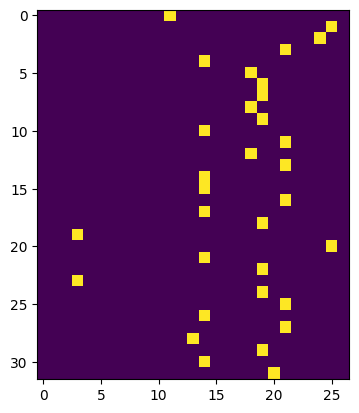

In [20]:
plt.imshow(F.one_hot(logits.max(1).indices, num_classes = logits.shape[1]))

In [21]:
dlogits += F.one_hot(logits.max(1).indices, num_classes = logits.shape[1]) * dlogit_maxes

cmp('logits', dlogits, logits)

logits          | exact: True  | approximate: True  | maxdiff: 0.0


*We have completed the backpropagation till cross entropy*

**Now, we will move into Layer-2** (output layer)

In [22]:
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)

cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)

h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0


In [23]:
# non-linearity (tanh)
dhpreact = (1.0 - h**2) * dh

cmp('hpreact', dhpreact, hpreact)

hpreact         | exact: False | approximate: True  | maxdiff: 5.820766091346741e-11


We have completed till non-linearity hidden layer

Next will be backpropagating through the **batch normalization layer**

Now,  
**hpreact = bngain * bnraw + bnbias**  

shapes:
    - hpreact : [32, 64]
    - bngain : [1, 64]
    - bnraw : [32, 64]
    - bnbias : [1, 64]

So,  
dbngain = dhpreact * bnraw --> size : [32, 64] but bngain : [1, 64]  
Therefore, **dbngain = (bnraw * dhpreact).sum(0, keepdim=True)** to make sure dimension is maintained

**dbnraw = bngain * dhpreact** --> size : [1, 64] (correct)

**dbnbias = dhpreact.sum(0, keepdim=True)**


In [24]:
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)

cmp('bngain', dbngain, bngain)
cmp('bnraw', dbnraw, bnraw)
cmp('bnbias', dbnbias, bnbias)

bngain          | exact: False | approximate: True  | maxdiff: 2.3283064365386963e-10
bnraw           | exact: False | approximate: True  | maxdiff: 1.1641532182693481e-10
bnbias          | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10


bnraw = bndiff * bnvar_inv

Shapes:
    - bnraw : [32, 64]
    - bndiff : [32, 64]
    - bnvar_inv : [1, 64]

Since it's simple element-wzie multiplication so calc. will be simple.  
Therefore,  
    **dbndiff = bnvar_inv * dbnraw** ---> size : [32, 64] (correct)  
    **dbnvar_inv = bndiff * dbnraw** ---> size : [32, 64], required : [1, 64]


***dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)***

In [25]:
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)

# cmp('bndiff', dbndiff, bndiff)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

bnvar_inv       | exact: False | approximate: True  | maxdiff: 3.4924596548080444e-10


In [26]:
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv

cmp('bnvar', dbnvar, bnvar)

bnvar           | exact: False | approximate: True  | maxdiff: 7.275957614183426e-11


In [27]:
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
cmp('bndiff2', dbndiff2, bndiff2)

bndiff2         | exact: False | approximate: True  | maxdiff: 2.2737367544323206e-12


In [28]:
dbndiff += (2 * bndiff) * dbndiff2
cmp('bndiff', dbndiff, bndiff)

bndiff          | exact: False | approximate: True  | maxdiff: 1.1641532182693481e-10


In [29]:
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)

# cmp('hprebn', dhprebn, hprebn)
cmp('bnmeani', dbnmeani, bnmeani)

bnmeani         | exact: False | approximate: True  | maxdiff: 2.9103830456733704e-10


In [30]:
dhprebn += (1.0/n ) * (torch.ones_like(hprebn)*  dbnmeani) 
cmp('hprebn', dhprebn, hprebn)


hprebn          | exact: False | approximate: True  | maxdiff: 1.1641532182693481e-10


completed the batchNorm layer backprop

In [31]:
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)

cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)

embcat          | exact: False | approximate: True  | maxdiff: 3.4924596548080444e-10
W1              | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
b1              | exact: False | approximate: True  | maxdiff: 2.3283064365386963e-10


In [32]:
demb = dembcat.view(emb.shape)

cmp('emb', demb, emb)

emb             | exact: False | approximate: True  | maxdiff: 3.4924596548080444e-10


emb = C[Xb]

Shapes:  
    - emb : [32, 3, 10]  
    - C : [27, 10]  
    - Xb : [32, 3]

In [33]:
dC = torch.zeros_like(C)

for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        idx = Xb[k, j]
        dC[idx] += demb[k, j]


cmp('C', dC, C)

C               | exact: False | approximate: True  | maxdiff: 8.731149137020111e-10


Verifying the our backprop result of cross entropy with pytorch's cross_entropy result

In [34]:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.363572597503662 diff: 0.0


In [35]:
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09


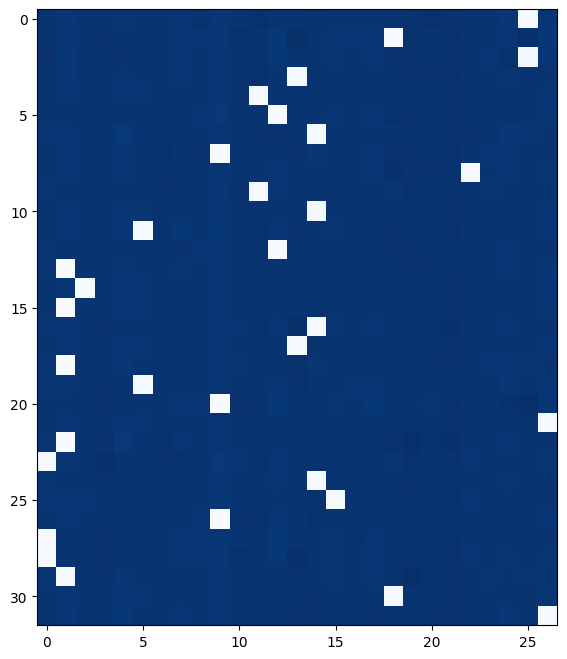

In [36]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap='Blues')

**Perform Backprop in one go**

In [37]:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff: ', (hpreact_fast - hpreact).abs().max())

max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [38]:
# backward pass
# we derived it manually through the calculation (noted down in notebook)
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 1.1641532182693481e-10


##### Everything putting together

In [39]:
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_tr[ix], Y_tr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    #loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! 
    # -----------------
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 2nd layer backprop
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way (using PyTorch grad from .backward())
      p.data += -lr * grad

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    if i >= 100: # TODO: delete early breaking when you're ready to train the full net
      break

12297
      0/ 200000: 3.8058


In [40]:
# compare our gradients with pytorch parameters
# for p,g in zip(parameters, grads):
    # cmp(str(tuple(p.shape)), g, p)

In [41]:
with torch.no_grad():
    emb = C[X_tr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [42]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (X_tr, Y_tr),
    'val': (X_val, Y_val),
    'test': (X_test, Y_test),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.6778979301452637
val 2.676868438720703


In [43]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahxqto.
hqvifkigrixreetl.
hklansaeja.
hnbn.
apliahc.
kaqhi.
oremari.
cemiiv.
kkleggph.
bma.
kin.
qhxjnhs.
ojewa.
vadbq.
wane.
ogdiarixi.
fkcekphlran.
ea.
ecoia.
gtlefay.
